In [1]:
!pip install tensorflow

In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, Dropout
from tensorflow.keras.models import Model

In [3]:
fashion_mnist= tf.keras.datasets.fashion_mnist
(x_train,y_train),(x_test,y_test) = fashion_mnist.load_data()
#carrega o dataset mnist

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
x_train,x_test = x_train /255.0,x_test / 255.0
# coloca os dados entre 0-1
print('x_train.shape:',x_train.shape)

x_train.shaoe: (60000, 28, 28)


In [ ]:
x_train = np.expand_dims(x_train,-1)
x_test = np.expand_dims(x_test,-1)
# como a rede espera 3d, enntao adicionamos mais uma dimensao
print(x_train.shape)

(60000, 28, 28, 1)


In [6]:
K = len(set(y_train))
# pega numero de classes
# evita hardcodar o numero de classes
print('number class: ',K)

number class:  10


In [7]:
i = Input(shape=x_train[0].shape)# camda de input, recebe as dimensoes dos dados, nesse caso 3D
x=Conv2D(32, (3,3),strides=2,activation='relu')(i)# primeira camada onde uma matriz 3x3 passa fazendo um feature map
x=Conv2D(64, (3,3),strides=2,activation='relu')(x) # aumenta os features mas para alcançar caracteristicas ainda nao visiveis
x=Conv2D(128, (3,3),strides=2,activation='relu')(x)
x=Flatten()(x)# achata tudo para um vetor
x=Dropout(rate=0.2)(x)# camada de desligamento de neuronios, evita overfitting
x=Dense(512, activation='relu')(x)#camada densa
x=Dropout(rate=0.2)(x)
x=Dense(K, activation='softmax')(x)# camda de saida que tem 10 neuronios de saida

model = Model(i,x)# coloca tudo no modelo Model

In [8]:
model.compile(optimizer='Adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])# atribui o otimizador de pesos, e as metricas
r=model.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=15)# trina o modelo, e depois testa com dados que nunca viu

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.8085 - loss: 0.5172 - val_accuracy: 0.8551 - val_loss: 0.3966
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8657 - loss: 0.3574 - val_accuracy: 0.8725 - val_loss: 0.3421
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8838 - loss: 0.3091 - val_accuracy: 0.8858 - val_loss: 0.3056
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8968 - loss: 0.2749 - val_accuracy: 0.8859 - val_loss: 0.3083
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9042 - loss: 0.2525 - val_accuracy: 0.8978 - val_loss: 0.2904
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9122 - loss: 0.2293 - val_accuracy: 0.8940 - val_loss: 0.2983
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9198 - loss: 0.2127 - val_accuracy: 0.8990 - val_loss: 0.2848
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9248 - loss: 0.1966 -

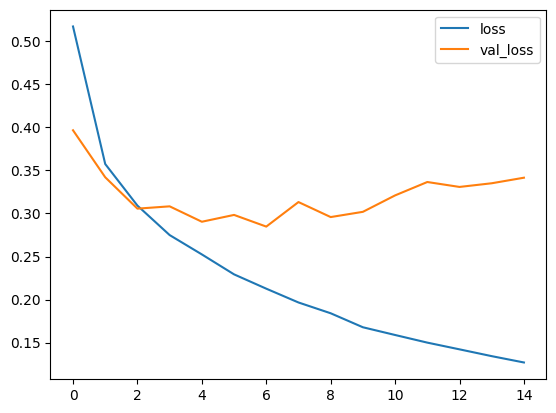

In [9]:
plt.plot(r.history['loss'],label='loss')
plt.plot(r.history['val_loss'],label='val_loss')
plt.legend()

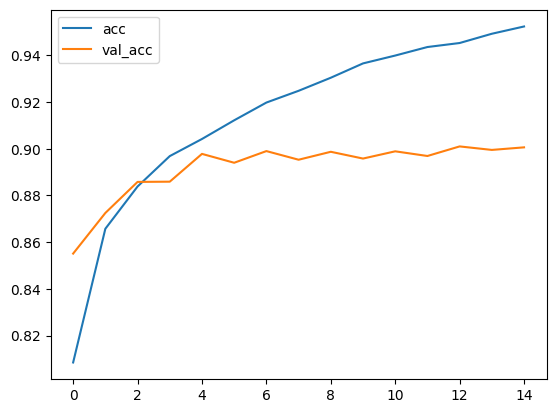

In [10]:
plt.plot(r.history['accuracy'],label='acc')
plt.plot(r.history['val_accuracy'],label='val_acc')
plt.legend()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


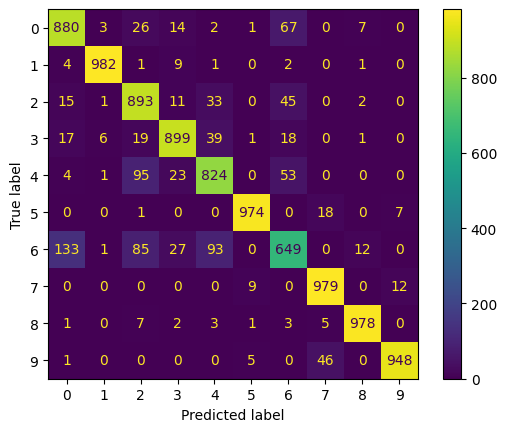

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred = model.predict(x_test).argmax(axis=1)
cm = confusion_matrix(y_test, y_pred)
#observando a matriz de confusao, podemos analisar que o modelo errou 133 vezes a classe 6, dizendo que era da clsse 0. Entao pode ter imagens parecidas entre as classes

matrix = ConfusionMatrixDisplay(confusion_matrix=cm)
matrix.plot()
plt.show()